was noch fehlt:

- Header (Emfehlung, Kurs, Zielkurs, Investmentstyle, GICS Sektor, Sub-Industrie)
- Kleine Intro
- Firmeninformationen
- DDM Model
- Industrie

In [1]:
import pandas as pd
from dotenv import load_dotenv
import os

from utils.fin.financial_data import key_figures, key_growth_rates, per_share_values, income_statement_overview, \
    balance_sheet_overview

load_dotenv(".env")

True

In [3]:
from utils.fetch_data import fetch_financial_data_yfinance, fetch_financial_data

dfs = fetch_financial_data_yfinance("JPM")
dfs = fetch_financial_data_yfinance("SPY")
dfs = fetch_financial_data("JPM", api_key=os.getenv("API_KEY"))

Saved: /home/btibor/Documents/repos/report/JPM_daily.json
Saved: /home/btibor/Documents/repos/report/JPM_balance.json
Saved: /home/btibor/Documents/repos/report/JPM_earnings.json
Saved: /home/btibor/Documents/repos/report/JPM_cash.json


In [2]:
from utils.load_data import load_stock_data, load_fundamental_data

stock = load_stock_data("JPM").reset_index().rename(columns={"index": "fiscalDateEnding"})
balance = load_fundamental_data("JPM", type="balance").reset_index().rename(columns={"index": "fiscalDateEnding"})
earnings = load_fundamental_data("JPM", type="earnings").reset_index().rename(columns={"index": "fiscalDateEnding"})
cash = load_fundamental_data("JPM", type="cash").reset_index().rename(columns={"index": "fiscalDateEnding"})


In [14]:
from utils.load_data import load_stock_data, load_fundamental_data
from utils.fetch_data import fetch_financial_data_yfinance, fetch_financial_data

dfs = fetch_financial_data_yfinance("SPY")
spy = load_stock_data("SPY").reset_index().rename(columns={"index": "fiscalDateEnding"})

Saved: /home/btibor/Documents/repos/report/SPY_daily.json


In [3]:
def normalize_datetime_column(df, col='fiscalDateEnding'):
    """Convert column to timezone-naive datetime."""
    df[col] = pd.to_datetime(df[col])
    if df[col].dt.tz is not None:
        df[col] = df[col].dt.tz_localize(None)
    return df

balance = normalize_datetime_column(balance)
earnings = normalize_datetime_column(earnings)
cash = normalize_datetime_column(cash)
stock = normalize_datetime_column(stock)


# Merge step by step
fundamental = pd.merge(balance, earnings, on='fiscalDateEnding', how='inner')
fundamental = pd.merge(fundamental, cash, on='fiscalDateEnding', how='inner')

stock_sorted = stock.sort_values('fiscalDateEnding')
fundamental_sorted = fundamental.sort_values('fiscalDateEnding')

# Merge as-of: for each stock date, take the most recent fundamental row with date <= stock date
fundamental_stock = pd.merge_asof(fundamental_sorted, stock_sorted, on='fiscalDateEnding', direction='backward')

In [4]:
print(fundamental_stock.info())

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 97 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   fiscalDateEnding                                           81 non-null     datetime64[us]
 1   reportedCurrency_x                                         81 non-null     str           
 2   totalAssets                                                81 non-null     int64         
 3   totalCurrentAssets                                         81 non-null     int64         
 4   cashAndCashEquivalentsAtCarryingValue                      81 non-null     int64         
 5   cashAndShortTermInvestments                                81 non-null     int64         
 6   inventory                                                  74 non-null     float64       
 7   currentNetReceivables                           

In [5]:
from utils.fin.key_metrics import calculate_financial_metrics

metrics_dict = calculate_financial_metrics(stock, fundamental_stock)

print("| Metric | Value |")
print("|--------|-------|")
for key, value in metrics_dict.items():
    print(f"| {key} | {value} |")

| Metric | Value |
|--------|-------|
| 2-Wochen Kursspanne | $20.75 |
| Stammaktien in Umlauf (Mrd) | 2.79 |
| Dividendensatz/Aktie | 0.00 |
| $10K investiert vor 5 J. | N/A |
| Marktkapitalisierung (Mrd) | $ 837.86 |
| Dividendenrendite (%) | 0% |
| Ø tägl. Handelsvolumen (M) | 10.80 |
| Beta | 1.36 |
| Moody’s Issuer Rating | Caa1 |


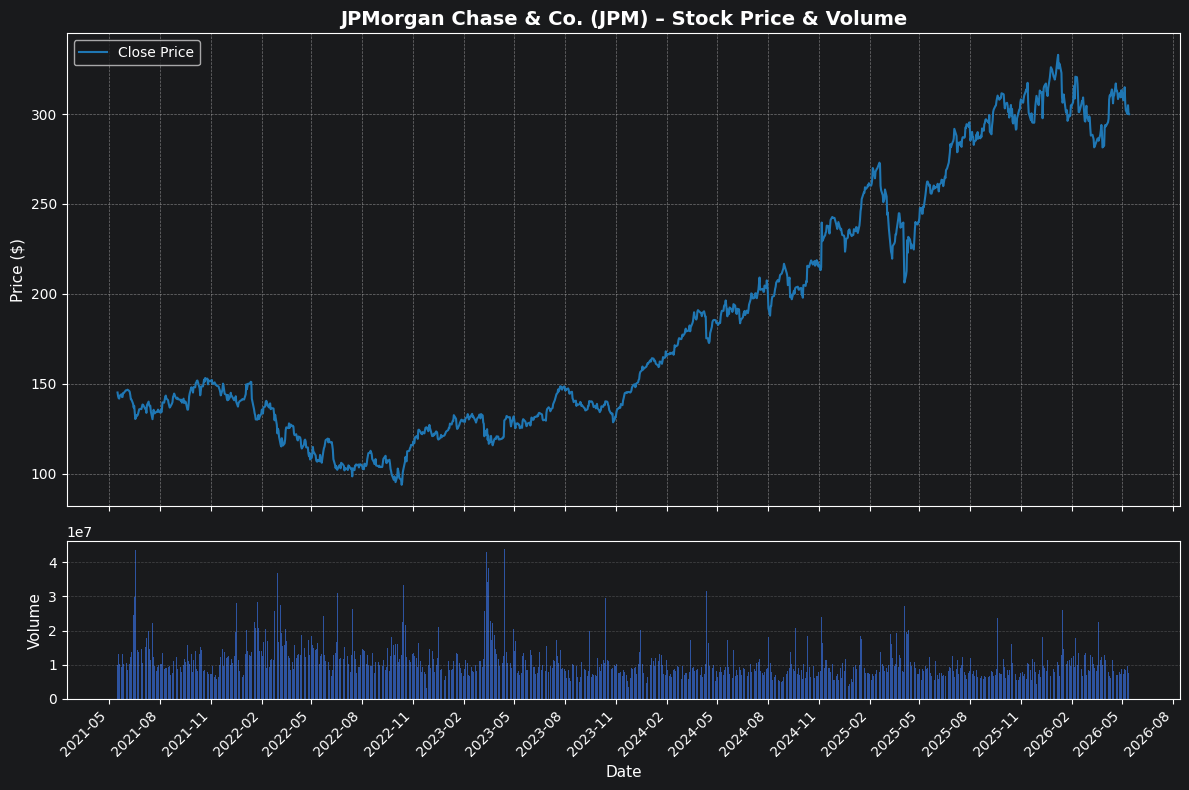

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

stock['fiscalDateEnding'] = pd.to_datetime(stock['fiscalDateEnding'])

stock = stock[stock['volume'] > 1000]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 8),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True
)

ax1.plot(stock['fiscalDateEnding'], stock['close'],
         color='#1f77b4', linewidth=1.5, label='Close Price')
ax1.set_ylabel('Price ($)', fontsize=11)
ax1.set_title(f'JPMorgan Chase & Co. (JPM) – Stock Price & Volume',
              fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

ax2.bar(stock['fiscalDateEnding'], stock['volume'],
        width=1, alpha=0.7)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Volume', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

## Gemini

In [ ]:
from utils.gemini import query_gemini

print(query_gemini(
"""
 Der Umsatz des 4. Quartals 2007 stieg auf $44.1 Milliarden, bei
Weitem mehr als die erwarteten rund $38.4 Milliarden.
▫ Nach monatelangen Verhandlungen verkündete die indische
Tata Motors Ltd am 26. März 2008 die Übernahme der beiden
Ford Marken Jaguar und Land Rover. Der Verkauf der
defizitären Luxus Marke Jaguar und der ebenfalls rote Zahlen
schreibenden Tochter Land Rover soll die Kassen von Ford MC
mit ungefähr $2.3 Mrd. füllen. Ford sollte es dadurch möglich
sein, sich auf den wichtigen Massenmarkt zu konzentrieren, um
so einen Weg aus der Verlustzone zu finden. (Kombinierter
Verlust von $15,393 Millionen in den Jahren 2006 & 2007)
▫ Der US Automarkt stellt aufgrund stetiger Marktanteilsverluste
aktuell das größte Problem für Ford dar. (Fords US Marktanteil
sank allein im 4. Quartal 2007 um 0.7 Prozentpunkte auf
14.1%.)

Please generate such a report for JPM. You have freedom what news choose but they should be new not old data.
Do not give me anything extra in the message on the points of the report, you found online.
And do not give anything extra in the message just the report. keep it the same lenth.
"""
))

In [ ]:
from utils.gemini import query_gemini

print(query_gemini(
"""
Die Ford Motor Company (FMC) ist ein global tätiges Unternehmen, mit den
Kerngeschäftsbereichen Automobile und Finanzdienstleistungen. Das
Automobilsegment beinhaltet folgende Kernaufgaben: Design, Entwicklung,
Herstellung, Verkauf und Service von PKWs, LKWs und Ersatzteilen. Die Ford Motor
Credit Company stellt ein ganzes Portfolio von Finanzdienstleistungen zur
Verfügung, konzentriert sich dabei jedoch hauptsächlich auf Finanzierung, Leasing
und Versicherung von Kraftfahrzeugen.
Ford ist der zweitgrößte Automobil- und Lastkraftwagenhersteller der Welt mit den
Hauptmarken Aston Martin, Ford, Jaguar, Land Rover, Lincoln, Mercury und Volvo.
Außerdem ist Ford mit 34% der Mehrheitseigentümer von Mazda. Ungefähr 80% des
Konzernumsatzes generiert Ford aus dem Verkauf von Automobilen, 2/3 davon in
Nordamerika. Die restlichen 20% werden mit den Finanzdienstleistungen der Ford
Motor Credit Company erzielt, hauptsächlich durch die Finanzierung der Ford
Vertragshändler aber auch durch die Inanspruchnahme verschiedenster
Finanzservices durch Firmen- und Privatkunden. The Autovermietung Hertz ist
ebenfalls Bestandteil der FMC. Nach der Gründung im Jahr 1903 fand Fords IPO im
Jahr 1956 statt.
Im Jahr 2006 fuhr Ford den größten Jahresverlust ($12.6 Mrd) in der
Firmengeschichte ein. Trotz eines Gewinns in der Höhe von $750 Millionen im
zweiten Quartal 2007 schloss die FMC auch das Geschäftsjahr 2007 mit einem
negativen Ergebnis ab ($2.7 Mrd). Dieser Verlust ist allerdings zum Großteil den
notwendigen Umstrukturierungen bei Volvo zuzuschreiben. Um die Betriebskosten
zu reduzieren und die Profitabilität des Unternehmens in Nordamerika zu erhöhen,
entwickelte die FMC eine langfristige Strategie, die neben einigen weiteren
Veränderungen die Schließung von 16 Standorten in den USA (bis zum Jahr 2012)
und die Reduzierung der Betriebskosten um jährlich $5 Mrd. bis 2008 umfasst.
Weiters werden Verkaufssteigerungen der neueren, bereits am Markt befindlichen
Modelle (US: Ford Expedition, Edge, Lincoln Navigator, Lincoln; Europa: Ford S-MAX,
Transit, Galaxy) anvisiert. Zusätzlich werden starke Wachstumsmärkte (Indien,
China) in Zukunft stärker in den Fokus der FMC rücken.
MARKTPROFIL. Ford hat weiterhin, sowohl am US-Heimmarkt als auch auf den
Überseemärkten, mit harter Konkurrenz zu kämpfen. Bis inklusive des 3. Quartals
2007 musste die FMC Marktanteilsverluste in den USA hinnehmen, hauptsächlich
aufgrund von Einbrüchen im Flottenvertrieb. Hinzu kommt, dass vor allem
japanische Unternehmen wie Toyota, Honda oder Nissan in zunehmendem Maße
auch den US Markt bearbeiten und in der Lage sind, Marktanteile zu gewinnen. Die
hohen Zugewinne dieser Konkurrenten beruhen u.A. darauf, dass
kraftstoffsparendere Autos nun auch in den USA gefragt sind und Ford ebenso wie
z.B. GM bis jetzt diesen Wünschen nur unzureichend nachgekommen ist. Weitere
Risikobereiche für Ford sind steigende Rohstoffpreise, härterer Preiswettbewerb
und Wechselkursschwankungen.

Please generate such a report for JPM. You have freedom what news choose but they should be new not old data.
Do not give me anything extra in the message on the points of the report, you found online.
And do not give anything extra in the message just the report. Keep it the same length.
"""
))

In [6]:
from utils.gemini import query_gemini

print(query_gemini(
"""
Die Ford Motor Company (FMC) ist ein global tätiges Unternehmen, mit den
Kerngeschäftsbereichen Automobile und Finanzdienstleistungen. Das
Automobilsegment beinhaltet folgende Kernaufgaben: Design, Entwicklung,
Herstellung, Verkauf und Service von PKWs, LKWs und Ersatzteilen. Die Ford Motor
Credit Company stellt ein ganzes Portfolio von Finanzdienstleistungen zur
Verfügung, konzentriert sich dabei jedoch hauptsächlich auf Finanzierung, Leasing
und Versicherung von Kraftfahrzeugen.
Ford ist der zweitgrößte Automobil- und Lastkraftwagenhersteller der Welt mit den
Hauptmarken Aston Martin, Ford, Jaguar, Land Rover, Lincoln, Mercury und Volvo.
Außerdem ist Ford mit 34% der Mehrheitseigentümer von Mazda. Ungefähr 80% des
Konzernumsatzes generiert Ford aus dem Verkauf von Automobilen, 2/3 davon in
Nordamerika. Die restlichen 20% werden mit den Finanzdienstleistungen der Ford
Motor Credit Company erzielt, hauptsächlich durch die Finanzierung der Ford
Vertragshändler aber auch durch die Inanspruchnahme verschiedenster
Finanzservices durch Firmen- und Privatkunden. The Autovermietung Hertz ist
ebenfalls Bestandteil der FMC. Nach der Gründung im Jahr 1903 fand Fords IPO im
Jahr 1956 statt.
Im Jahr 2006 fuhr Ford den größten Jahresverlust ($12.6 Mrd) in der
Firmengeschichte ein. Trotz eines Gewinns in der Höhe von $750 Millionen im
zweiten Quartal 2007 schloss die FMC auch das Geschäftsjahr 2007 mit einem
negativen Ergebnis ab ($2.7 Mrd). Dieser Verlust ist allerdings zum Großteil den
notwendigen Umstrukturierungen bei Volvo zuzuschreiben. Um die Betriebskosten
zu reduzieren und die Profitabilität des Unternehmens in Nordamerika zu erhöhen,
entwickelte die FMC eine langfristige Strategie, die neben einigen weiteren
Veränderungen die Schließung von 16 Standorten in den USA (bis zum Jahr 2012)
und die Reduzierung der Betriebskosten um jährlich $5 Mrd. bis 2008 umfasst.
Weiters werden Verkaufssteigerungen der neueren, bereits am Markt befindlichen
Modelle (US: Ford Expedition, Edge, Lincoln Navigator, Lincoln; Europa: Ford S-MAX,
Transit, Galaxy) anvisiert. Zusätzlich werden starke Wachstumsmärkte (Indien,
China) in Zukunft stärker in den Fokus der FMC rücken.
MARKTPROFIL. Ford hat weiterhin, sowohl am US-Heimmarkt als auch auf den
Überseemärkten, mit harter Konkurrenz zu kämpfen. Bis inklusive des 3. Quartals
2007 musste die FMC Marktanteilsverluste in den USA hinnehmen, hauptsächlich
aufgrund von Einbrüchen im Flottenvertrieb. Hinzu kommt, dass vor allem
japanische Unternehmen wie Toyota, Honda oder Nissan in zunehmendem Maße
auch den US Markt bearbeiten und in der Lage sind, Marktanteile zu gewinnen. Die
hohen Zugewinne dieser Konkurrenten beruhen u.A. darauf, dass
kraftstoffsparendere Autos nun auch in den USA gefragt sind und Ford ebenso wie
z.B. GM bis jetzt diesen Wünschen nur unzureichend nachgekommen ist. Weitere
Risikobereiche für Ford sind steigende Rohstoffpreise, härterer Preiswettbewerb
und Wechselkursschwankungen.

Please generate such a report for JPM and its industry. You have freedom what infos to choose but they should be new not old data.
Do not give me anything extra in the message on the points of the report, you found online.
And do not give anything extra in the message just the report. Keep it the same length.
"""
))

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [7]:
from utils.gemini import query_gemini

print(query_gemini(
"""
TRENGHTS. Ford ist einer der größten Autohersteller der
Welt und weist ein Portfolio mehrerer Marken auf. Fords R&D
Abteilung konzentriert Ressourcen derzeit auf die
Verbesserung von Performance und Sicherheit, der
Treibstoffeffizienz und der Kundenzufriedenheit.
WEAKNESSES. Obwohl namhafte Konkurrenten längst mit
umweltschonenden und treibstoffsparenden Autos auf dem
US-Markt sind, legte Ford auch in den vergangenen Jahren
sein Hauptaugenmerk vor allem auf SUVs. Durch die
Preissteigerungen bei Treibstoffen und Energie im
Allgemeinen könnte die Profitabilität dieses Marktes
allerdings noch weiter einbrechen.
OPPORTUNITIES. Präsenz in neuen Märkten: In Indien und
China rechnet sich Ford starke Wachstumschancen aus.
THREATS. Härtere Konkurrenten: Toyota, Honda und Nissan
konnten ihre US Marktanteile ausbauen. Weitere Risiken:
steigende Kosten für Rohmaterialien, stärkerer
Preiswettbewerb und ungünstige Wechselkursfluktuationen.

Please generate such a SWOT analysis for JPM. You have freedom what infos to choose but they should be new not old data.
Do not give me anything extra in the message on the points of the report, you found online.
And do not give anything extra in the message just the report. Keep it the same length.
"""
))

**SWOT-Analyse für JPMorgan Chase (JPM)**

**STÄRKEN.** JPMorgan Chase ist mit über 4 Billionen US-Dollar an verwalteten Vermögenswerten die weltweit größte Bank nach Marktkapitalisierung und erzielt Rekordgewinne in allen Geschäftsbereichen. Das Unternehmen verfügt über ein stark diversifiziertes Portfolio an Finanzdienstleistungen und eine globale Präsenz in über 100 Ländern. Durch strategische Übernahmen wie die der First Republic Bank im Jahr 2023 konnte JPM seine Marktposition stärken und das Kundensegment der vermögenden Privatkunden ausbauen. Zudem ist das Unternehmen führend in der technologischen Innovation, insbesondere im Bereich Blockchain mit JPM Coin und tokenisierten Geldmarktfonds.

**SCHWÄCHEN.** JPMorgan Chase wurde mit erheblichen regulatorischen Strafen belegt, darunter 250 Millionen US-Dollar im Jahr 2020 wegen Mängeln im Risikomanagement und 98,2 Millionen US-Dollar im Jahr 2024 wegen unzureichender Überwachung von Handelsaktivitäten. Die deutsche Finanzaufsichtsb

In [8]:
from utils.gemini import query_gemini

print(query_gemini(
"""
anuary 4, 2008
Toyota overtakes Ford in US
Toyota overtook Ford Motor last year as the number two
carmaker in the US, shattering Detroit's long dominance
of the world's biggest vehicle market. The Japanese
carmaker sold 2.62m vehicles in the US in 2007, up 2.7
per cent from the previous year. Ford's sales slumped 12
per cent to 2.57m units.
January 8, 2008
Ford to Invest $500 Million to Boost Production
Capacity in India
Ford Motor Co., furthering its push into emerging
markets, plans to invest $500 million to double its
production capacity in India and start making a small,
inexpensive car for the country's growing middle class.
Ford said during the next two years it will raise annual
capacity at its plants in the southern state of Tamil Nadu
to 250,000 engines and 200,000 cars from the current
50,000 engines and 100,000 cars.
January 13, 2008
Ford Unveils Small Car to Meet Fuel-Economy Demand
Ford unveiled its second small-car prototype, trying to
tap demand for more fuel-efficient vehicles. The fourdoor Verve sedan is smaller than the Focus, Ford's main
small car. Ford plans to start sales by 2010 on a North
American version of the Verve, based on the model
displayed today at the Detroit auto show.
January 24, 2008
Ford to offer buyouts to 54,000 workers
Ford Motor Co. will offer buyout and early retirement
packages to 54,000 U.S. hourly workers in an effort to cut
costs and replace those leaving with lower-paid workers.
Thursday's announcement came as Ford said it narrowed
its losses in 2007 but warned that the outlook for U.S.
sales in 2008 remains grim.
February 1, 2008
Ford, Toyota Say January U.S. Sales Fell; GM Gains.
Ford Motor Co., Chrysler LLC and most Asian
automakers said U.S. sales fell in January, setting the
industry on a course for its third straight year of
decline. Ford reported a 3.9 percent drop in light
vehicles. Toyota Motor Corp., the Japanese
automaker that passed Ford to become second in
the U.S. last year, slid along with Honda Motor Co.
and Nissan Motor Co. No. 1 General Motors Corp.
posted a surprise gain and scaled back planned
production cuts.
March 3, 2008
GM, Ford, Toyota Post Declines in U.S. February
Sales. General Motors Corp., Ford Motor Co.,
Chrysler LLC and Toyota Motor Corp. said sales fell
in February as rising fuel prices and a slowing
economy dragged the industry to its steepest
decline in seven months. GM's light-vehicle sales
dropped 12.9 percent, Ford's slipped 6.6 percent
and Chrysler was down 14 percent
March 28, 2008
Tata pledge on Jaguar and Land Rover. Tata, whose
automotive division is negotiating to buy Jaguar and
Land Rover from Ford Motor, has no plans to
"Indianise" the UK carmakers, its chairman said
yesterday. Tata gave clearest indications yet that his
group will retain the brands' British character and
leave their management largely intact after buying
them from Ford later this year.
March 28, 2008
EU inquiry deadline into Tata Motors. The European
Commission said the deadline for its inquiry into
Indian car maker Tata Motors Ltd's proposed $2.3b
acquisition of Ford Motor Co's Jaguar and Land
Rover brands is set for April 30

Please generate such a news reprt for JPM. You have freedom what news to choose but they should be new not old data and important.
Do not give me anything extra in the message on the points of the report, you found online.
And do not give anything extra in the message just the report.
Keep the overall message, wording and the amount of news +-1 the same length.
"""
))

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

## Viz

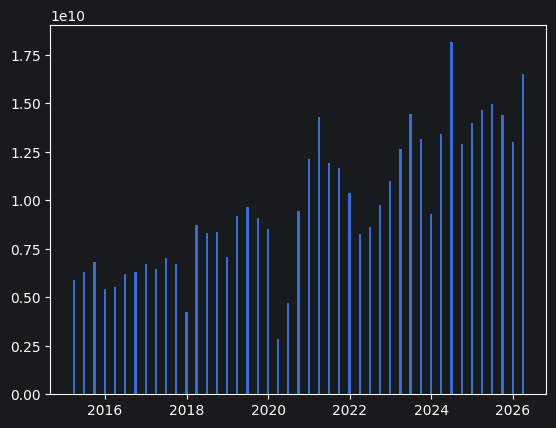

In [7]:
start_date = '2015-01-01'
filtered = earnings[earnings['fiscalDateEnding'] >= start_date]

fig, ax = plt.subplots()
ax.bar(filtered['fiscalDateEnding'], filtered['netIncome'], width=20)
plt.show()

In [9]:
# First, compute per‑share metrics
fundamental_stock['EPS'] = fundamental_stock['netIncome_x'] / fundamental_stock['commonStockSharesOutstanding']
fundamental_stock['FCF'] = fundamental_stock['operatingCashflow'] - fundamental_stock['capitalExpenditures']
fundamental_stock['FCFPS'] = fundamental_stock['FCF'] / fundamental_stock['commonStockSharesOutstanding']
fundamental_stock['KGV'] = fundamental_stock['close'] / fundamental_stock['EPS']   # P/E ratio

# Now prepare the wide table for the last 5 years
fundamental_stock['year'] = fundamental_stock['fiscalDateEnding'].dt.year

# Keep first report per year (oldest first)
fundamental_stock = fundamental_stock.sort_values('fiscalDateEnding')
first_per_year = fundamental_stock.groupby('year').first().reset_index()

# Select last 5 years
last5_years = sorted(first_per_year['year'].unique())[-5:]

# Choose the metrics you want (per‑share and valuation)
metrics = ['close', 'EPS', 'KGV', 'FCFPS']
# Create wide DataFrame: rows = metrics, columns = years

wide_df = first_per_year[first_per_year['year'].isin(last5_years)].set_index('year')[metrics].T

In [14]:
print(fundamental_stock.info())

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Columns: 109 entries, fiscalDateEnding to Konzernumsatz je Aktien
dtypes: datetime64[us](1), float64(61), int32(1), int64(43), str(3)
memory usage: 68.8 KB
None


In [5]:
import utils.fin.financial_data

print(key_figures(fundamental_stock))
print(key_growth_rates(fundamental_stock))
print(per_share_values(fundamental_stock))
print(income_statement_overview(fundamental_stock))
print(balance_sheet_overview(fundamental_stock))

year         2022        2023        2024        2025        2026
close  126.073898  119.307854  190.911819  236.758835  282.325134
EPS      2.778262    4.245972    4.606907    5.184648    5.903998
KGV     45.378688   28.099070   41.440342   45.665368   47.819312
FCFPS  -14.061389  -37.420863  -52.924334  -89.168644  -75.799477
                      1 Jahr   3 Jahren    5 Jahren    8 Jahren
totalRevenue        6.899154  34.809026  119.020576  128.123258
netIncome_x        12.640852  30.676596   15.342657   89.325069
EPS                13.874632  39.049403   27.117625  135.800758
DividendsPerShare  15.665953  37.944699   50.971745  143.637454
year                             2022         2023         2024         2025  \
Gewinn je Aktie              2.778262     4.245972     4.606907     5.184648   
Dividende je Aktie           1.150621     1.134995     1.199190     1.353610   
Ausstehende Aktien (Mio)  2981.000000  2972.700000  2912.800000  2824.300000   
Buchwert je Aktie           95

In [16]:
print(fundamental.info())

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 92 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   fiscalDateEnding                                           81 non-null     datetime64[us]
 1   reportedCurrency_x                                         81 non-null     str           
 2   totalAssets                                                81 non-null     int64         
 3   totalCurrentAssets                                         81 non-null     int64         
 4   cashAndCashEquivalentsAtCarryingValue                      81 non-null     int64         
 5   cashAndShortTermInvestments                                81 non-null     int64         
 6   inventory                                                  74 non-null     float64       
 7   currentNetReceivables                           

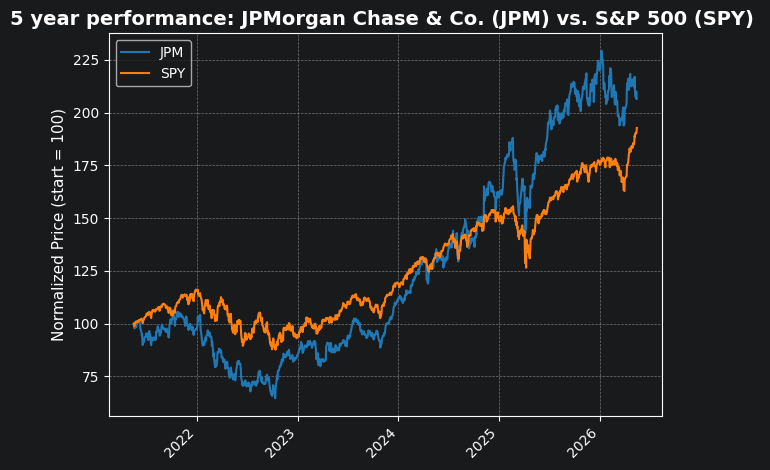

In [17]:
stock['normalized'] = stock['close'] / stock['close'].iloc[0] * 100
spy['normalized'] = spy['close'] / spy['close'].iloc[0] * 100

fig, ax1 = plt.subplots()

ax1.plot(stock['fiscalDateEnding'], stock['normalized'],
         color='#1f77b4', linewidth=1.5, label='JPM')
ax1.plot(spy['fiscalDateEnding'], spy['normalized'],
         color='#ff7f0e', linewidth=1.5, label='SPY')

ax1.set_ylabel('Normalized Price (start = 100)', fontsize=11)
ax1.set_title('5 year performance: JPMorgan Chase & Co. (JPM) vs. S&P 500 (SPY) ',
              fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()